# File Dokumen: Data Cleaning Harga Bahan Pokok.ipynb
file ini berisi tentang data cleaning harga bahan pokok di pasar tradisional di Jakarta, Indonesia. Data ini mencakup informasi tentang harga berbagai bahan pokok seperti beras, minyak goreng, gula, dan lainnya. Tujuan dari data cleaning ini adalah untuk membersihkan dan mempersiapkan data for analisis lebih lanjut. Proses data cleaning melibatkan langkah-langkah seperti menghapus duplikasi, menangani nilai yang hilang, memperbaiki format data, dan mengidentifikasi serta menangani outlier. Data yang telah dibersihkan akan lebih akurat dan dapat diandalkan for analisis tren harga, perbandingan harga antar pasar, dan prediksi harga di masa depan. Data ini dapat digunakan oleh pedagang, konsumen, dan pembuat kebijakan for memahami dinamika harga bahan pokok dan membuat keputusan yang lebih baik.

## Import Dataset

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path1 = 'dataset/PIHPS_Jakarta_Full_2021_2026.csv'
path2 = '../dataset/PIHPS_Jakarta_Full_2021_2026.csv'

if os.path.exists(path1):
    path = path1
elif os.path.exists(path2):
    path = path2
else:
    raise FileNotFoundError("Neither file path exists.")

df_harga = pd.read_csv(path, sep=',', skipinitialspace=True)
df_harga.info()

<class 'pandas.DataFrame'>
RangeIndex: 1386 entries, 0 to 1385
Data columns (total 32 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Tanggal                          1386 non-null   str  
 1   Bawang Merah                     1386 non-null   str  
 2   Bawang Merah Ukuran Sedang       1386 non-null   str  
 3   Bawang Putih                     1386 non-null   str  
 4   Bawang Putih Ukuran Sedang       1386 non-null   str  
 5   Beras                            1386 non-null   str  
 6   Beras Kualitas Bawah I           1386 non-null   str  
 7   Beras Kualitas Bawah II          1386 non-null   str  
 8   Beras Kualitas Medium I          1386 non-null   str  
 9   Beras Kualitas Medium II         1386 non-null   str  
 10  Beras Kualitas Super I           1386 non-null   str  
 11  Beras Kualitas Super II          1386 non-null   str  
 12  Cabai Merah                      1386 non-null   str  
 13 

## Data Cleaning

In [2]:
# ubah format tanggal
df_harga["Tanggal"] = pd.to_datetime(df_harga["Tanggal"], errors='coerce')
df_harga = df_harga.dropna(subset=['Tanggal'])

# Clean column names and convert price columns to numeric
df_harga.columns = df_harga.columns.str.strip()
harga_columns = [col for col in df_harga.columns if col != 'Tanggal']

for col in harga_columns:
    # Ensure it's string, remove commas and dashes, strip spaces
    df_harga[col] = df_harga[col].astype(str).str.replace(',', '', regex=False).str.replace('-', '', regex=False).str.strip()
    # Convert to numeric, empty strings become NaN
    df_harga[col] = pd.to_numeric(df_harga[col], errors='coerce')

# Sort by date
df_harga = df_harga.sort_values("Tanggal")

# Lakukan interpolasi linier pada semua kolom harga
df_harga[harga_columns] = df_harga[harga_columns].interpolate(method='linear')

# Gunakan bfill untuk mengisi baris awal yang mungkin masih NaN
df_harga[harga_columns] = df_harga[harga_columns].bfill()

df_harga.info()

<class 'pandas.DataFrame'>
RangeIndex: 1386 entries, 0 to 1385
Data columns (total 32 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Tanggal                          1386 non-null   datetime64[us]
 1   Bawang Merah                     1386 non-null   float64       
 2   Bawang Merah Ukuran Sedang       1386 non-null   float64       
 3   Bawang Putih                     1386 non-null   float64       
 4   Bawang Putih Ukuran Sedang       1386 non-null   float64       
 5   Beras                            1386 non-null   float64       
 6   Beras Kualitas Bawah I           1386 non-null   float64       
 7   Beras Kualitas Bawah II          1386 non-null   float64       
 8   Beras Kualitas Medium I          1386 non-null   float64       
 9   Beras Kualitas Medium II         1386 non-null   float64       
 10  Beras Kualitas Super I           1386 non-null   float64       
 11  Be

In [3]:
df_harga.head()

,Tanggal,Bawang Merah,Bawang Merah Ukuran Sedang,Bawang Putih,Bawang Putih Ukuran Sedang,Beras,Beras Kualitas Bawah I,Beras Kualitas Bawah II,Beras Kualitas Medium I,Beras Kualitas Medium II,...,Daging Sapi Kualitas 2,Gula Pasir,Gula Pasir Kualitas Premium,Gula Pasir Lokal,Minyak Goreng,Minyak Goreng Curah,Minyak Goreng Kemasan Bermerk 1,Minyak Goreng Kemasan Bermerk 2,Telur Ayam,Telur Ayam Ras Segar
0,2021-01-01,35000.0,35000.0,35850.0,35850.0,13450.0,12150.0,11300.0,13950.0,12750.0,...,123350.0,15100.0,15500.0,14650.0,14950.0,14850.0,15000.0,15000.0,25650.0,25650.0
1,2021-01-04,35000.0,35000.0,35850.0,35850.0,13450.0,12150.0,11300.0,13950.0,12750.0,...,123350.0,15100.0,15500.0,14650.0,14950.0,14850.0,15000.0,15000.0,25650.0,25650.0
2,2021-01-05,35000.0,35000.0,35850.0,35850.0,13450.0,12150.0,11300.0,13950.0,12750.0,...,123350.0,15100.0,15500.0,14650.0,14950.0,14850.0,15000.0,15000.0,25650.0,25650.0
3,2021-01-06,33350.0,33350.0,35850.0,35850.0,13450.0,12150.0,11300.0,13950.0,12750.0,...,123350.0,15100.0,15500.0,14650.0,14950.0,14850.0,15000.0,15000.0,25500.0,25500.0
4,2021-01-07,33350.0,33350.0,35850.0,35850.0,13450.0,12150.0,11300.0,13950.0,12750.0,...,122500.0,15000.0,15350.0,14650.0,14950.0,14850.0,15000.0,15000.0,25350.0,25350.0


## Cek Missing Values

In [4]:
# Periksa nilai yang hilang
df_harga.isna().sum()

Tanggal                            0
Bawang Merah                       0
Bawang Merah Ukuran Sedang         0
Bawang Putih                       0
Bawang Putih Ukuran Sedang         0
Beras                              0
Beras Kualitas Bawah I             0
Beras Kualitas Bawah II            0
Beras Kualitas Medium I            0
Beras Kualitas Medium II           0
Beras Kualitas Super I             0
Beras Kualitas Super II            0
Cabai Merah                        0
Cabai Merah Besar                  0
Cabai Merah Keriting               0
Cabai Rawit                        0
Cabai Rawit Hijau                  0
Cabai Rawit Merah                  0
Daging Ayam                        0
Daging Ayam Ras Segar              0
Daging Sapi                        0
Daging Sapi Kualitas 1             0
Daging Sapi Kualitas 2             0
Gula Pasir                         0
Gula Pasir Kualitas Premium        0
Gula Pasir Lokal                   0
Minyak Goreng                      0
M

## Set Index dan Simpan Data

In [5]:
# Set index ke kolom Tanggal
harga_time = df_harga.set_index("Tanggal")
harga_time.sort_index(inplace=True)
harga_time.head()

,Bawang Merah,Bawang Merah Ukuran Sedang,Bawang Putih,Bawang Putih Ukuran Sedang,Beras,Beras Kualitas Bawah I,Beras Kualitas Bawah II,Beras Kualitas Medium I,Beras Kualitas Medium II,Beras Kualitas Super I,...,Daging Sapi Kualitas 2,Gula Pasir,Gula Pasir Kualitas Premium,Gula Pasir Lokal,Minyak Goreng,Minyak Goreng Curah,Minyak Goreng Kemasan Bermerk 1,Minyak Goreng Kemasan Bermerk 2,Telur Ayam,Telur Ayam Ras Segar
Tanggal,,,,,,,,,,,,,,,,,,,,,
2021-01-01,35000.0,35000.0,35850.0,35850.0,13450.0,12150.0,11300.0,13950.0,12750.0,16350.0,...,123350.0,15100.0,15500.0,14650.0,14950.0,14850.0,15000.0,15000.0,25650.0,25650.0
2021-01-04,35000.0,35000.0,35850.0,35850.0,13450.0,12150.0,11300.0,13950.0,12750.0,16350.0,...,123350.0,15100.0,15500.0,14650.0,14950.0,14850.0,15000.0,15000.0,25650.0,25650.0
2021-01-05,35000.0,35000.0,35850.0,35850.0,13450.0,12150.0,11300.0,13950.0,12750.0,16350.0,...,123350.0,15100.0,15500.0,14650.0,14950.0,14850.0,15000.0,15000.0,25650.0,25650.0
2021-01-06,33350.0,33350.0,35850.0,35850.0,13450.0,12150.0,11300.0,13950.0,12750.0,16350.0,...,123350.0,15100.0,15500.0,14650.0,14950.0,14850.0,15000.0,15000.0,25500.0,25500.0
2021-01-07,33350.0,33350.0,35850.0,35850.0,13450.0,12150.0,11300.0,13950.0,12750.0,16350.0,...,122500.0,15000.0,15350.0,14650.0,14950.0,14850.0,15000.0,15000.0,25350.0,25350.0


In [6]:
# save data yang sudah dibersihkan ke file baru
harga_time.to_csv('../dataset/PIHPS_Jakarta_Cleaned_2021_2026.csv', index=True)

# Export khusus data Cabai Merah Besar
df_cabe_mb = harga_time[['Cabai Merah Besar']]
df_cabe_mb.to_csv('../dataset/dataset_cabe_mb_cleaned.csv', index=True)
print("Data Cabai Merah Besar berhasil disimpan di ../dataset/dataset_cabe_mb_cleaned.csv")

Data Cabai Merah Besar berhasil disimpan di ../dataset/dataset_cabe_mb_cleaned.csv


## Visualisasi Tren Harga

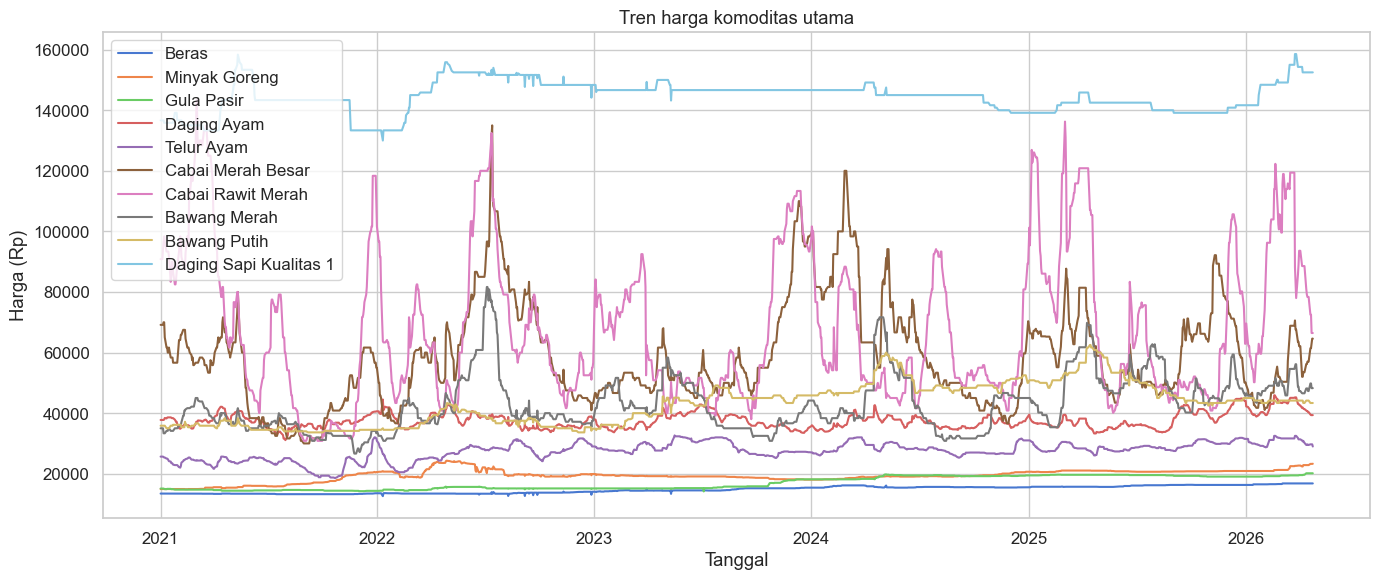

In [7]:
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# Visualisasi tren harga beberapa komoditas utama
selected = [
    "Beras",
    "Minyak Goreng",
    "Gula Pasir",
    "Daging Ayam",
    "Telur Ayam",
    "Cabai Merah Besar",
    "Cabai Rawit Merah",
    "Bawang Merah",
    "Bawang Putih",
    "Daging Sapi Kualitas 1"
]
selected = [c for c in selected if c in harga_time.columns]
plt.figure(figsize=(14, 6))
for col in selected:
    plt.plot(harga_time.index, harga_time[col], label=col)

plt.legend(loc="upper left")
plt.title("Tren harga komoditas utama")
plt.xlabel("Tanggal")
plt.ylabel("Harga (Rp)")
plt.tight_layout()
plt.show()

In [8]:
df_cabe_mb.head()

,Cabai Merah Besar
Tanggal,
2021-01-01,69150.0
2021-01-04,69150.0
2021-01-05,69150.0
2021-01-06,70000.0
2021-01-07,70000.0


In [9]:
df_cabe_mb.tail()

,Cabai Merah Besar
Tanggal,
2026-04-20,61450.0
2026-04-21,61450.0
2026-04-22,63100.0
2026-04-23,64600.0
2026-04-24,64600.0
